In [2]:
import numpy as np
import cv2

import torch
from torchvision.transforms import functional as VF

import onnx
import onnxruntime

from matplotlib import pyplot as plt

In [3]:
session = onnxruntime.InferenceSession("/Users/n-zagainov/kolobok/ml/onnx/sidewall_segmentator.onnx")

In [4]:
input_path = "/Users/n-zagainov/kolobok/ml/data/annotations/1.jpg"
image = cv2.imread(input_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_tensor = torch.tensor(image).permute(2, 0, 1).unsqueeze(0) / 255

In [5]:
image_resized = VF.resize(image_tensor, (512, 512))

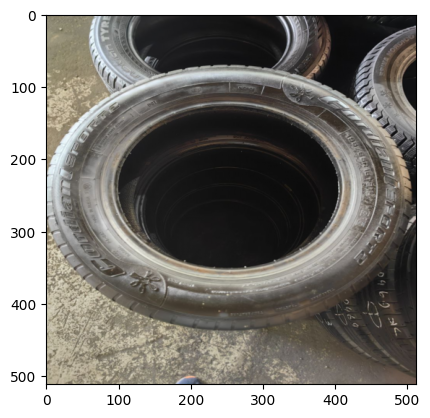

In [6]:
plt.imshow(image_resized[0].permute(1, 2, 0))

In [7]:
output = session.run(
    None,
    {
        "input": image_resized.numpy(),
    },
)

In [8]:
output

[array([[[[ -6.7986794,  -8.016543 ,  -7.527612 , ...,  -9.148749 ,
            -9.511325 ,  -8.599814 ],
          [ -7.8818336,  -7.4083366,  -6.679574 , ...,  -7.4710464,
            -8.115997 , -10.03117  ],
          [ -7.1816416,  -6.8470545,  -5.8899326, ...,  -9.199892 ,
            -9.964149 , -10.182117 ],
          ...,
          [-14.92295  , -13.715373 , -13.416495 , ...,  -6.835776 ,
            -5.8065   ,  -5.5399356],
          [-14.996888 , -14.154867 , -14.353627 , ...,  -8.990616 ,
            -9.753594 ,  -9.666821 ],
          [-14.50859  , -16.387268 , -15.832176 , ...,  -8.988852 ,
           -10.29958  , -10.515026 ]]]], dtype=float32)]

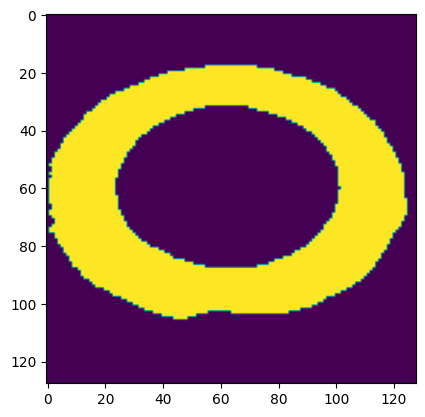

In [53]:
plt.imshow(output[0, 0] > 0)